# Digital Information Processing Lab 2025
---
<img align="left" src="https://www.cd.ovgu.de/cd_media/CD_OVGU/Downloads/Logo_jpg_png_svg_EPS_pdf/Logodownload/OVGU_Logo-download-1-p-1950.png" alt="drawing" width="350" />

### &emsp; Class 1: Final report
### &emsp; Group 12 : Night Owl
### &emsp; 10.05.2025

---

Name | Mat. Nr. | Email
--------|---------|---------
Vaibhav Roy | 248956 | vaibhav.roy@st.ovgu.de


# Preparatory task


## Task 1. Explain the relationship between square wave and sine wave signals



The relationship between rectangular and sinusoidal signals can be explained through Fourier series. A rectangular signal can be expressed as an infinite sum of sinusoidal signals, where each term in the sum is a harmonic of the fundamental frequency. The amplitude and phase of each harmonic are determined by the shape of the rectangular signal. In contrast, a sinusoidal signal is itself a single harmonic and can be considered the simplest form of a periodic signal. When a rectangular signal is filtered through a low-pass filter, the resulting output is a sinusoidal signal with the same fundamental frequency as the rectangular signal. This is because the low-pass filter removes all the harmonics of the rectangular signal except for the fundamental frequency, which is preserved in the output. Thus, we can see that rectangular signals and sinusoidal signals are intimately connected, and that the Fourier series provides a powerful tool for analyzing and understanding this relationship
<a name="text_about_square_waves"></a>
[<sup>[1]</sup>](#kuphaldt_refference1)

![picture](https://www.allaboutcircuits.com/uploads/articles/sum-of-harmonics-approximates-square-wave-diagram3.jpg)


Sum of 1st, 3rd, 5th, 7th and 9th harmonics approximates square wave.
<a name="picture_harmonics"></a>
[<sup>[2]</sup>](#kuphaldt_refference2)






## Task 2. Describe the sampling schematically and use it to explain the formula for sampling in the time domain.

The formula for sampling in time domain is:
$$
x_s(t) = x(t) \cdot \sum_{n=-\infty}^{\infty} \delta(t - nT_s)\quad \quad    (1)
$$

Where, \\
***Xs(t)*** is the sampled signal.

***x(t)*** is the original continuous-time signal.

***delta(t - nT_s)*** is the Dirac delta function, representing an impulse occuring at each sampling instant t = nTs.

***T_s*** is the sampling period (the time interval between successive samples.).

***n*** it is an integer indication of smaple position with the input data.

***t*** is the continuous time variable.

The above equation states that the sample signal X_s(t) is obtained by doing multiplication of original signal x(t) with an infinite sequence of impulses. These impulse are in interval of Ts at discrete times, capuring its values of x(t) at each instant. This leads to, conversion of continous-time signal into a disctre sets of value, which make it easy for doing digital analysis and for signal processing.

<div align="left">
  <img src="https://upload.wikimedia.org/wikipedia/commons/c/c3/Signal_Sampling.svg" width="300"/>
</div>

<p align="center">
  $$
  \text{Fig. 1: Signal sampling representation}
  $$
</p>

Sampling of the Waveform
<a name="sampling_anchor"></a>  
[<sup>[3]</sup>](#wikipedia_reference1)


# Class 1: Sampling and Reconstruction


## Exercise 1: Ploting

Generate signals and display them:

* sine
* rectangle
* triangle

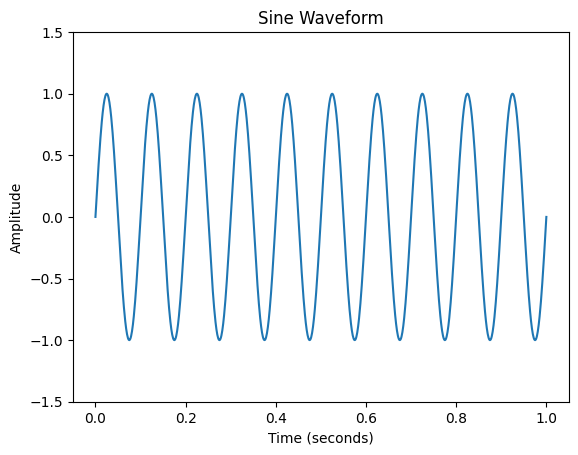

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sine_wave(amplitude, frequency, phase, duration):
    """Plots a sine wave with the given parameters."""
    # Generate time samples
    t = np.linspace(0, duration, 1000)

    # Compute the sine wave
    y = amplitude * np.sin(2 * np.pi * frequency * t + phase)

    # Plot the waveform
    plt.plot(t, y)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.ylim(top=1.5, bottom=-1.5)
    plt.title('Sine Waveform')
    plt.show()

plot_sine_wave(amplitude=1, frequency=10, phase=0, duration=1)

This function takes four arguments: amplitude, frequency, phase, and duration. The amplitude parameter sets the maximum amplitude of the sine wave, the frequency parameter sets the frequency of the sine wave in hertz, the phase parameter sets the phase offset of the sine wave in radians, and the duration parameter sets the length of time in seconds over which the sine wave is plotted.

(consider looking into a [plotting](https://matplotlib.org/stable/tutorials/index.html#tutorials) tutorial)

`plot_sine_wave(amplitude=1, frequency=10, phase=0, duration=1)` displays a sine wave with the frequency of 10 hz in the timespan of 1 s.



In [ ]:
def plot_square_wave(amplitude, frequency, phase, duration):
    """Plots a square wave with the given parameters."""
    # Generate time samples
    t = np.linspace(0, duration, 1000)

    # Compute the square wave
    y = amplitude * np.sign(np.sin(2 * np.pi * frequency * t + phase))

    # Plot the waveform
    plt.plot(t, y)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title('Square Waveform')
    plt.show()

In [ ]:
def plot_triangle_wave(amplitude, frequency, phase, duration):
    """Plots a triangle wave with the given parameters."""
    # Generate time samples
    t = np.linspace(0, duration, 1000)

    # Compute the triangle wave
    y = amplitude * np.abs(2 * np.mod(t * frequency + phase, 1.0) - 1) - amplitude/2

    # Plot the waveform
    plt.plot(t, y)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title('Triangle Waveform')
    plt.show()

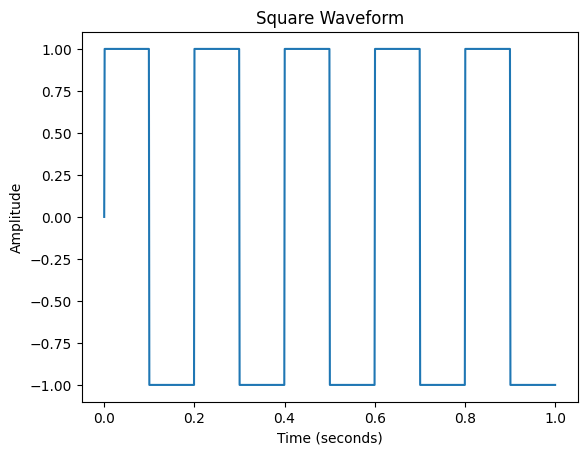

In [ ]:
plot_square_wave(amplitude=1, frequency=5, phase=0, duration=1)


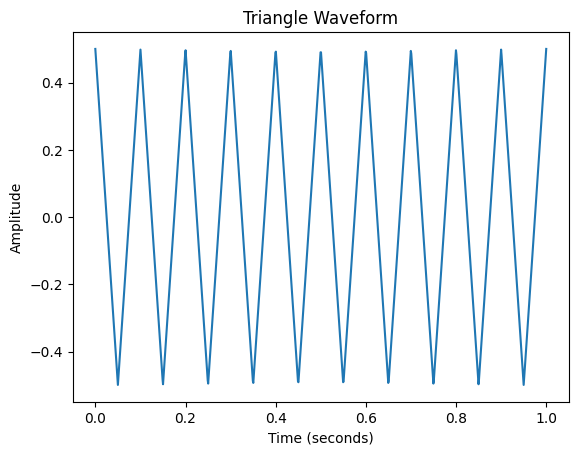

In [ ]:
plot_triangle_wave(amplitude=1, frequency=10, phase=0, duration=1)

These functions work similarly to the `plot_sine_wave` function. The `plot_square_wave` function takes five arguments: amplitude, frequency, duty_cycle, phase, and duration. The amplitude, frequency, phase, and duration parameters work the same as in the `plot_sine_wave function`. The duty_cycle parameter sets the percentage of time that the square wave is in the high state. This function generates a square wave using the np.sign and np.mod functions.

The `plot_triangle_wave` function takes four arguments: amplitude, frequency, phase, and duration. This function generates a triangle wave using the np.abs and np.mod functions.

## Interactive plots

You can use "widgets" to adjust the parameters for different functions. In this case, we use two "sliders" to adjust the frequency and amplitude. To ensure that the output also changes when a change is made, there is an "Observer" function that runs when a change is made.


## Exercise 2a: interactive plot

* Write a function that displays all three signal types in one plot on top of each other in different colors.
* Use sliders to change settings add a button to reset values


Here is some code for help:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display, clear_output

# Time vector
t = np.linspace(0, 1, 1000, endpoint=False)

# Default parameters
init_params = {
    'sine_freq': 1.0, 'sine_amp': 1.0, 'sine_phase': 0.0,
    'square_freq': 1.0, 'square_amp': 0.8, 'square_phase': 0.0,
    'saw_freq': 1.0, 'saw_amp': 0.6, 'saw_phase': 0.0,
}

# Create widgets
sine_freq = widgets.FloatSlider(description='Sine Freq', value=1.0, min=0.1, max=20.0, step=0.1)
sine_amp = widgets.FloatSlider(description='Sine Amp', value=1.0, min=0.1, max=2.0, step=0.1)
sine_phase = widgets.FloatSlider(description='Sine Phase', value=0.0, min=0.0, max=2*np.pi)

square_freq = widgets.FloatSlider(description='Square Freq', value=1.0, min=0.1, max=20.0, step=0.1)
square_amp = widgets.FloatSlider(description='Square Amp', value=0.8, min=0.1, max=2.0, step=0.1)
square_phase = widgets.FloatSlider(description='Square Phase', value=0.0, min=0.0, max=2*np.pi)

saw_freq = widgets.FloatSlider(description='Saw Freq', value=1.0, min=0.1, max=20.0, step=0.1)
saw_amp = widgets.FloatSlider(description='Saw Amp', value=0.6, min=0.1, max=2.0, step=0.1)
saw_phase = widgets.FloatSlider(description='Saw Phase', value=0.0, min=0.0, max=2*np.pi)

reset_btn = widgets.Button(description="Reset", button_style='info')

# Output area
output = widgets.Output()

# Update plot function
def update_plot(*args):
    with output:
        clear_output(wait=True)

        # Generate signals
        sine = sine_amp.value * np.sin(2 * np.pi * sine_freq.value * t + sine_phase.value)
        square = square_amp.value * signal.square(2 * np.pi * square_freq.value * t + square_phase.value)
        saw = saw_amp.value * signal.sawtooth(2 * np.pi * saw_freq.value * t + saw_phase.value)

        # Plot
        plt.figure(figsize=(10, 5))
        plt.plot(t, sine, label='Sine', color='blue')
        plt.plot(t, square, label='Square', color='green')
        plt.plot(t, saw, label='Sawtooth', color='red')
        plt.title('Signal Visualization (Colab Compatible)')
        plt.xlabel('Time [s]')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.ylim(-2, 2)
        plt.legend()
        plt.show()

# Reset function
def reset_values(b):
    for key, widget in zip(init_params, [
        sine_freq, sine_amp, sine_phase,
        square_freq, square_amp, square_phase,
        saw_freq, saw_amp, saw_phase
    ]):
        widget.value = init_params[key]


# Bind events
for w in [sine_freq, sine_amp, sine_phase,
          square_freq, square_amp, square_phase,
          saw_freq, saw_amp, saw_phase]:
    w.observe(update_plot, names='value')

reset_btn.on_click(reset_values)

# Display everything
display(widgets.VBox([
    sine_freq, sine_amp, sine_phase,
    square_freq, square_amp, square_phase,
    saw_freq, saw_amp, saw_phase,
    reset_btn, output
]))

# Initial plot
update_plot()


The above code helps to show sinc, square amd triangle waveforms all on same graph. It uses `update_plot` to genertae the plots with several parameters adjustments where needed. For showing sinc, square, triangle waveform it uses `np.sin`, `signal.square`, `signal.sawtooth` respectively to display each type of waveform.
You can adjust the waveforms by changing the values of phase, duration, amplitude,and frequency with the help of sliders. The graph adjust itself by changing the sliders values no need for further coding. If we want to get our original settings we have one option called" Reset values" button.

## Exercise 2b: interactive addition of two sine signals

Write a function that adds and displays two sinusoidal signals.
* The signals should be adjustable in frequency and phase
* The individual signals and the resulting signal should be displayed

Here is some code snipets for help:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Fixed parameters ---
AMPLITUDE = 1
DURATION = 1  # seconds

# --- Sine wave generator ---
def generate_sine(frequency, phase):
    t = np.linspace(0, DURATION, 1000)
    y = AMPLITUDE * np.sin(2 * np.pi * frequency * t + phase)
    return t, y

# --- Output widget ---
output = widgets.Output()

# --- Plotting function ---
def plot_sum_of_sinusoids(freq1, freq2, phase1, phase2):
    t, y1 = generate_sine(freq1, phase1)
    _, y2 = generate_sine(freq2, phase2)
    y_sum = y1 + y2

    with output:
        clear_output(wait=True)
        plt.figure(figsize=(10, 5))
        plt.plot(t, y1, label='Sine Wave 1', color='blue')
        plt.plot(t, y2, label='Sine Wave 2', color='green')
        plt.plot(t, y_sum, label='Sum of Sine Waves', color='red', linewidth=2)
        plt.title("Addition of Two Sine Waves")
        plt.xlabel("Time (seconds)")
        plt.ylabel("Amplitude")
        plt.ylim(-2.5, 2.5)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

# --- Initial slider values ---
initial_values = {
    'freq1': 2,
    'freq2': 3,
    'phase1': 0,
    'phase2': 0,
}

# --- Sliders ---
sliders = {
    'freq1': widgets.FloatSlider(value=initial_values['freq1'], min=0.1, max=10, step=0.1, description='Freq 1:'),
    'freq2': widgets.FloatSlider(value=initial_values['freq2'], min=0.1, max=10, step=0.1, description='Freq 2:'),
    'phase1': widgets.FloatSlider(value=initial_values['phase1'], min=-np.pi, max=np.pi, step=np.pi/8, description='Phase 1:'),
    'phase2': widgets.FloatSlider(value=initial_values['phase2'], min=-np.pi, max=np.pi, step=np.pi/8, description='Phase 2:'),
}

# --- Reset Button ---
def reset_sliders(b):
    for key in sliders:
        sliders[key].value = initial_values[key]

reset_button = widgets.Button(description='Reset values', button_style='info')
reset_button.on_click(reset_sliders)

# --- Observer to update plot ---
def update_plot(change=None):
    plot_sum_of_sinusoids(
        sliders['freq1'].value,
        sliders['freq2'].value,
        sliders['phase1'].value,
        sliders['phase2'].value,
    )

for slider in sliders.values():
    slider.observe(update_plot, names='value')

# --- Display interface ---
display(widgets.VBox([*sliders.values(), reset_button, output]))

# --- Initial plot ---
plot_sum_of_sinusoids(**initial_values)


This part of code provides an interactive tool which helps you to explore how two sinc waves combine. By using sliders ypu can adjust the settings of waveforms.
`freq_1` and `phase_1` for adjusting frequency and phasor angle  of first sinc wave respectively while
`freq_2` and `phase_2` for adjusting frequency and phasor angle of second sinc wave respectively.
As we adjust these values with sliders no need of further coding plots will update automatically as well as no need for second time run.
The sinc  waves are generated using the `plot_sinc_wave function`, which was earlier introduced in Exercise 1. The combined result is shown using a widget called `output_sum`.
To differentiate the appereance the phase sliders have an green color while for frequnce we have an light blue color.  

## Excercise 3a: sampling

Try out sampling of the different signals

* Sine signal
* Triangular signal
* Square wave signal

Compare the sampled signal with the original signal, while variating the sampling frequency.

* What observations can be made?
* What frequency is necessary to recognise the signal?


In [ ]:
def generate_sine_wave(amplitude, frequency, phase, duration):
    """Generates a sine wave with the given parameters."""
    # Generate time samples
    t = np.linspace(0, duration, int(duration*44100))
    # Compute the sine wave
    y = amplitude * np.sin(2 * np.pi * frequency * t + phase)
    return y

def generate_square_wave(amplitude, frequency, duty_cycle, phase, duration):
    """Generates a square wave with the given parameters."""
    # Generate time samples
    t = np.linspace(0, duration, int(duration*44100))
    # Compute the square wave
    y = amplitude * np.sign(np.sin(2 * np.pi * frequency * t + phase))
    # Set the duty cycle
    y[np.mod(t, 1.0/frequency) > duty_cycle/frequency] = -amplitude

    return y

def generate_triangle_wave(amplitude, frequency, phase, duration):
    """Generates a triangle wave with the given parameters."""
    # Generate time samples
    t = np.linspace(0, duration, int(duration*44100))

    # Compute the triangle wave
    y = amplitude * np.abs(2 * np.mod(t * frequency + phase, 1.0) - 1) - amplitude/2

    return y

def sample_waveform(waveform, frequency, duration):
    """Samples the given waveform at the given frequency."""
    # Generate time samples
    t = np.linspace(0, duration, int(duration*frequency))
    # Sample the waveform
    y = np.interp(t, np.linspace(0, duration, len(waveform)), waveform)

    return y



These functions all work the same as in Excercise 1, but now they return the generated waveforms as NumPy arrays instead of plotting them directly. The new sample_waveform function takes three arguments: waveform, which is the waveform to be sampled, frequency, which is the sampling frequency in Hz, and duration, which is the duration of the sampled waveform in seconds. This function uses the np.interp function to resample the waveform at the desired sampling frequency.

New


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Constants ---
DURATION_SEC = 1.0
RESOLUTION = 1000
TIME_GRID = np.linspace(0, DURATION_SEC, RESOLUTION, endpoint=False)

# --- Output area ---
output_area = widgets.Output()

# --- Waveform calculation ---
def create_waveform(wave_kind, freq, amp, phase_shift, duty_factor):
    angular_wave = 2 * np.pi * freq * TIME_GRID + phase_shift
    if wave_kind == 'Sine':
        return amp * np.sin(angular_wave)
    elif wave_kind == 'Square':
        return amp * signal.square(angular_wave, duty=duty_factor)
    elif wave_kind == 'Triangle':
        return amp * signal.sawtooth(angular_wave, width=0.5)
    raise ValueError(f"Unknown waveform: {wave_kind}")

def sample_signal(continuous_signal, fs_rate):
    t_s = np.linspace(0, DURATION_SEC, int(fs_rate * DURATION_SEC), endpoint=False)
    y_s = np.interp(t_s, TIME_GRID, continuous_signal)
    return t_s, y_s

# --- Interactive elements ---
waveform_picker = widgets.ToggleButtons(
    options=['Sine', 'Square', 'Triangle'],
    description='Wave Type:',
    style={'description_width': 'initial'}
)

freq_slider = widgets.FloatSlider(value=5.0, min=0.1, max=30.0, step=0.1, description='Freq [Hz]')
amp_slider = widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='Amplitude')
phase_slider = widgets.FloatSlider(value=0.0, min=0.0, max=2*np.pi, step=0.1, description='Phase [rad]')
duty_slider = widgets.FloatSlider(value=0.5, min=0.1, max=0.9, step=0.05, description='Duty Cycle')
fs_slider = widgets.FloatSlider(value=5.0, min=1.0, max=100.0, step=1.0, description='Sampling Rate [Hz]')
reset_button = widgets.Button(description='Reset All', button_style='danger')

# --- Plotting logic ---
def refresh_plot(*_):
    with output_area:
        clear_output(wait=True)

        # Get parameters
        wave = create_waveform(
            wave_kind=waveform_picker.value,
            freq=freq_slider.value,
            amp=amp_slider.value,
            phase_shift=phase_slider.value,
            duty_factor=duty_slider.value
        )

        t_sampled, y_sampled = sample_signal(wave, fs_slider.value)

        # Plot setup
        plt.figure(figsize=(10, 4))
        plt.plot(TIME_GRID, wave, label='Continuous', linewidth=2)
        plt.plot(t_sampled, y_sampled, 'ro', label='Sampled Points')
        plt.plot(t_sampled, y_sampled, 'k--', alpha=0.4, label='Sampled Signal')
        plt.title(f'{waveform_picker.value} Wave with Sampling')
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.ylim(-2, 2)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()

# --- Reset function ---
def restore_defaults(_):
    waveform_picker.value = 'Sine'
    freq_slider.value = 5.0
    amp_slider.value = 1.0
    phase_slider.value = 0.0
    duty_slider.value = 0.5
    fs_slider.value = 12.0

# --- Event bindings ---
for ctrl in [waveform_picker, freq_slider, amp_slider, phase_slider, duty_slider, fs_slider]:
    ctrl.observe(refresh_plot, names='value')

reset_button.on_click(restore_defaults)

# --- Layout ---
generate_waveform = widgets.VBox([
    waveform_picker,
    freq_slider,
    amp_slider,
    phase_slider,
    duty_slider,
    fs_slider,
    reset_button
])

# --- Display ---
display(generate_waveform, output_area)
refresh_plot()


Output()

In this section, the function `generate_waveform` is used to generate a waveform based on user-defined parameters using the `create_waveform` function. It displays the result of original and sampled versions for the sack of our better comparison.

The interface also includes interactive sliders, which allow us to pick anyone of waveform like Sinc, Square or Triangle and we can adjust the settings of frequency, amplitude, phase, duty cycle and sampling rate. As we change the values using sliders plot changes automaticaaly which shows us how sampling really affects the waveforms.

The important observation that we made by looking at the waveform is that: for higher frequencies we need high sampling rate to avoid the effect of aliasing. If we change duty cycle then it will only affect the square waveform which shows PWM behaviour. We can also observe that for higher sampling rate we will get the accurate signals while in case of lower sampling rate the signals will be distorted. This are the key importanc that can observe from the waveforms.

An important concept in digital signal processing is the Nyquist–Shannon sampling theorem, which connects a signal's frequency range with the sample rate needed to prevent aliasing, a form of distortion. According to the theory, in order to prevent aliasing, the sample rate needs to be at least twice the signal's bandwidth. When an analog signal is sampled or sample rates are altered within a digital signal processing function, it is used to choose band-limiting filters to keep aliasing within a reasonable level. <a name="sampling_anchor"></a>  
[<sup>[3]</sup>](#wikipedia_reference1)

$$
f_s \geq 2f_{\max} \tag{2}
$$



## Exercise 3b: advanced sampling methods

Create a plot using different sampling functions:
* Zero-order hold
* Sinc Reconsturcion
* Linear interpolation of sampled values

Compare the graphs.

* What differences can be seen ?

New

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy import signal

# --- Fixed parameters ---
duration = 2.0  # Duration in seconds
t_cont = np.linspace(0, duration, 1000)

# --- Interactive controls ---
freq_slider = widgets.FloatSlider(value=1.0, min=0.1, max=10.0, step=0.1, description='Frequency')
amp_slider = widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='Amplitude')
sr_slider = widgets.IntSlider(value=10, min=2, max=30, step=1, description='Sampling Rate')
wave_selector = widgets.ToggleButtons(options=['Sine', 'Square', 'Triangle'], description='Wave')
reset_button = widgets.Button(description='Reset', button_style='info')

output = widgets.Output()

def generate_signal(t, wave, freq, amp):
    if wave == 'Sine':
        return amp * np.sin(2 * np.pi * freq * t)
    elif wave == 'Square':
        return amp * signal.square(2 * np.pi * freq * t)
    elif wave == 'Triangle':
        return amp * signal.sawtooth(2 * np.pi * freq * t, width=0.5)

def zero_order_hold(t, t_s, x_s):
    return x_s[np.searchsorted(t_s, t, side='right') - 1]

def linear_interp(t, t_s, x_s):
    return np.interp(t, t_s, x_s)

def sinc_interp(t, t_s, x_s, sr):
    y = np.zeros_like(t)
    for n, val in enumerate(x_s):
        y += val * np.sinc((t - t_s[n]) * sr)
    return y

def generate_plot(change=None):
    with output:
        clear_output(wait=True)

        freq = freq_slider.value
        amp = amp_slider.value
        sr = sr_slider.value
        wave = wave_selector.value

        t_s = np.arange(0, duration, 1/sr)
        y_s = generate_signal(t_s, wave, freq, amp)
        y_cont = generate_signal(t_cont, wave, freq, amp)

        plt.figure(figsize=(10, 5))
        plt.plot(t_cont, y_cont, 'k-', label='Original')
        plt.plot(t_s, y_s, 'ro', label='Samples')
        plt.plot(t_cont, zero_order_hold(t_cont, t_s, y_s), 'b-', label='Zero-Order Hold')
        plt.plot(t_cont, linear_interp(t_cont, t_s, y_s), 'g-', label='Linear Interpolation')
        plt.plot(t_cont, sinc_interp(t_cont, t_s, y_s, sr), 'm-', label='Sinc Interpolation')

        plt.title(f"{wave} Wave - Sampling and Reconstruction")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.ylim(-1.5 * amp, 1.5 * amp)
        plt.grid(True)
        plt.legend()
        plt.show()

def reset_values(b):
    freq_slider.value = 1.0
    amp_slider.value = 1.0
    sr_slider.value = 10
    wave_selector.value = 'Sine'
    generate_plot()

# Attach callbacks
freq_slider.observe(update_plot, names='value')
amp_slider.observe(update_plot, names='value')
sr_slider.observe(update_plot, names='value')
wave_selector.observe(update_plot, names='value')
reset_button.on_click(reset_values)

# Display UI and initial plot
ui = widgets.VBox([
    wave_selector,
    freq_slider,
    amp_slider,
    sr_slider,
    reset_button
])

display(ui, output)
generate_plot()


Output()

The ` generate_plot` function is an interactive tool that allows us to explore how different types of waveforms generated such sinc, square, triangle further it uses to sampled and reconstruct our original waveforms using different interpolation techniques. Users can changes the paramenters such as sampling frequency and amplitude to see how these parameters affect the reconstruction process. It allows us to visualizes the original signals, its sampled version and the reconstructions using common methods such as : zero-order hold, sinc interpolation, and linear interpolation. This methods allows us to get a clear idea of  comparision of how precisely each method help us to regain the original signals from the sampled datas.
From the generated plots, we observe that zero-order hold (ZOH) interpolation generated a staircase signals. This method help us to keeps the amplitude of signal remains the same between sampling points, results into an piecewise flat waveform. Because it does not show us the real behaviour between samples, it introdeces the sudden transitions and is especially prone to ditortion when reconstructing very high-frequency content. The mathematical expression for ZOH can be given as:<a name="wendemuth_anchor"></a>  
[<sup>[4]</sup>](#wendemuth_reference1)
$$
xd(t)=x(kT_s​)\quad \quad (3) $$ for $$kT_s ≤t<(k+1)T_s\quad \quad (4)
$$
On the contradictorily, a more better approach of the original waveform is obtain by using sinc interpolation. The equation for sinc reconstruction can be given as: $$
   x(t) = \sum_{n=1}^{\infty} x(m)sinc \{\pi(\frac{t}{T_{s}}-m)\}  \quad \quad (5)
$$



Sinc interpolation is especially good at keeping the original shape of waveform and reducing distortion, particularly for signals with fast changes or high frequencies. The key to how well it works lies in something called the reconstruction factor, which controls how wide the sinc functions are:


'Smaller reconstruction factor': Narrows the sinc functions. This interpolation focuses more tightly around the sampled points, which helps capture the fine details in the signal. If the sampling rate is not high enough then it causes unwanted aliasing.


'Larger reconstruction factor': Wider the sinc functions. This spreads interpolition more over the signal leading into a smoother signal. But it makes the signal blur and may miss some datas from the original signal.


On the other hand, linear interpolition connects the dots between the sample points with straight lines. This method is better that the method of zero-order hold, but not accurate as sinc interpolition when it comes to present complex signal details.

To sum up both the method discussed so far sinc interpolation provides most accurate reconstruction of the original signal, especially when sampling rate is adequate and the reconstruction factor is well chosen. While linear interpolation serves as a simpler alternative approach with moderate performance, while zero-order hold, though easy to implement, often results in distortion.</a>  
[<sup>[4]</sup>](#wikipedia_reference1)


##References##

<a name="kuphaldt_refference1"></a>
1. [^](#text_about_square_waves) T. R. Kuphaldt, Libretexts, “8.2: Square wave signals,” Workforce LibreTexts, Mar. 20, 2021. https://workforce.libretexts.org/Bookshelves/Electronics_Technology/Book%3A_Electric_Circuits_II_-_Alternating_Current_(Kuphaldt)/08%3A_Mixed-Frequency_AC_Signals/8.02%3A_Square_Wave_Signals

<a name="kuphaldt_refference2"></a>
2. [^](#picture_harmonics) T. R. Kuphaldt, “Square wave signals,” Mixed-Frequency AC Signals | Electronics Textbook, Jan. 11, 2021. https://www.allaboutcircuits.com/textbook/alternating-current/chpt-7/square-wave-signals/
<a name="kuphaldt_refference3"></a>

<a name="wikipedia_reference1"></a>  
3. [^](#sampling_anchor) “Sampling (signal processing),” *Wikipedia*, Last edited April 1, 2021. [https://en.wikipedia.org/w/index.php?title=Sampling_(signal_processing)&oldid=1289454724](https://en.wikipedia.org/w/index.php?title=Sampling_(signal_processing)&oldid=1289454724)

<a name="Wendemuth_book"></a>
4. [^](#book) Andreas Wendemuth, "Grundlagen der digitalen Signalverarbeitung", Springer-Verlag Berlin Heidelberg 2005, doi:https://doi.org/10.1007/b138044


